In [2]:
#7.1
import numpy as np
import numpy.linalg as la

A=np.array([[1,2,3],[0,-4,1],[0,3,-1]])
print(A)
det=la.det(A)
print(det)
b=np.array([2,2,-1])
sol=la.solve(A,b)
print(sol)
print(f"Is A orthogonal: {np.allclose(A.T,la.inv(A))}")
lam,v=la.eig(A)
print(f"The eigenvalues are: {lam}")

[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
1.0
[10. -1. -2.]
Is A orthogonal: False
The eigenvalues are: [ 1.         -4.79128785 -0.20871215]


In [24]:
#7.3
def Ex(a):
    a=np.radians(a)
    return np.array([[1,0,0],[0,np.cos(a),np.sin(a)],[0,(-1)*np.sin(a),np.cos(a)]])
def Ey(a):
    a=np.radians(a)
    return np.array([[np.cos(a),0,-np.sin(a)],[0,1,0],[np.sin(a),0,np.cos(a)]])
def Ez(a):
    a=np.radians(a)
    return np.array([[np.cos(a),np.sin(a),0],[(-1)*np.sin(a),np.cos(a),0],[0,0,1]])
E=la.multi_dot((Ez(180-123),Ey(90-27.4),Ez(192.25)))
print(E)
print(f'E is a rotation matrix: {np.allclose(E.T,la.inv(E)) and la.det(E)==1}')
print(la.eig(E)[0])
v = [-0.86760081, -0.1883746, 0.46019978]
print(la.norm(v))
v2=np.dot(E,v)
print(v2)

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
E is a rotation matrix: True
[-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
0.9999999964749322
[ 7.32356596e-10 -3.77054967e-09  9.99999996e-01]


1000 1000


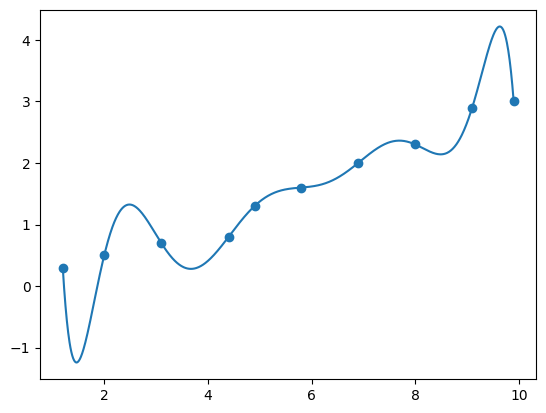

In [3]:
#7.5
from matplotlib.pyplot import figure, show
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
A=[]
for i in range(len(x)):
    for j in range(len(x)-1,-1,-1):
        A.append(x[i]**j)

A=np.array(A)
A.shape=(len(x),len(x))

a=la.solve(A,y)
fig=figure()
frame=fig.add_subplot(1,1,1)
frame.scatter(x,y)
x0=np.linspace(x.min(),x.max(),1000)
y0=[]
for i in range(len(x0)):
    k=0
    for j in range(len(a)):
        k+=x0[i]**j*a[len(a)-j-1]
    y0.append(k)
print(len(x0),len(y0))
frame.plot(x0,y0)
show()

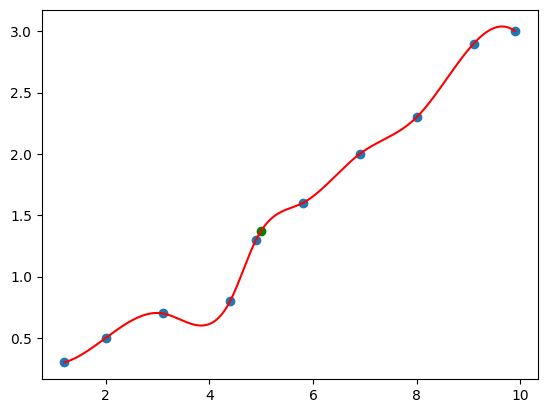

In [62]:
#7.6
from scipy import interpolate as ip
f=ip.interp1d(x,y, kind='cubic')
fig=figure()
frame=fig.add_subplot(1,1,1)
frame.scatter(x,y)
frame.plot(x0,f(x0),color='r')


class interpolation:
    def __init__(self,x1,y1):
        self.x=x1
        self.y=y1
        
    def ip(self,kind):
        return ip.interp1d(self.x,self.y,kind)
    
    def xip(self,x2,kind):
        if self.x.min()<=x2<=self.x.max():
            f=self.ip(kind)
            return f(x2)
        else:
            print('Wrong value')
            
inter=interpolation(x,y)
y0=inter.xip(5,'cubic')
frame.scatter(5,y0,color='g')
show()

In [7]:
#7.7
def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

I = np.array([[2.0,4.1], [2.5,3.8]])
x=0.2
y=0.7
Intp=bilinearIP(I,y,x)
print(Intp)

3.4579999999999993


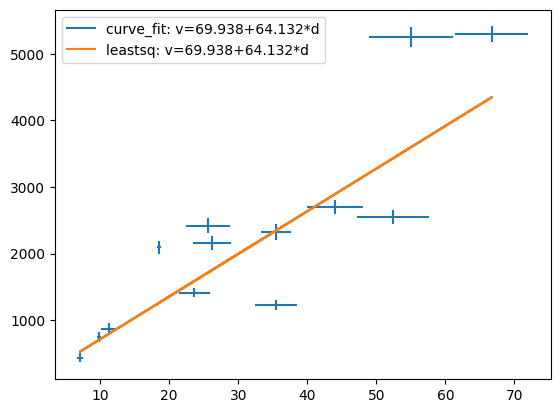

In [24]:
#7.10
from scipy.optimize import leastsq, curve_fit
data = np.array([
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
])
data=data.reshape((int(data.size/4),4))
d=data[:,0]
v=data[:,1]
errd=data[:,2]
errv=data[:,3]
def f(x,a,b):
    return a+b*x
beta,pcov=curve_fit(f,d,v,sigma=errv,absolute_sigma=True)
v1=f(d,*beta)

beta_start = [0, 70.0]
def residuals(beta, x, y, sigy):
    return (y - f(x,*beta))/sigy
data = (d, v, errv)
result = leastsq(residuals, beta_start, args=data, full_output=1)
(beta2, pcov, infodict, errmsg, ier) = result
v2=f(d,*beta2)
fig=figure()
frame=fig.add_subplot(1,1,1)
frame.errorbar(d,v,xerr=errd,yerr=errv,fmt='none')
frame.plot(d,v1,label=f"curve_fit: v={beta[0]:.3f}+{beta[1]:.3f}*d")
frame.plot(d,v2,label=f"leastsq: v={beta2[0]:.3f}+{beta2[1]:.3f}*d")
frame.legend(loc='upper left')
show()

In [ ]:
#7.14
